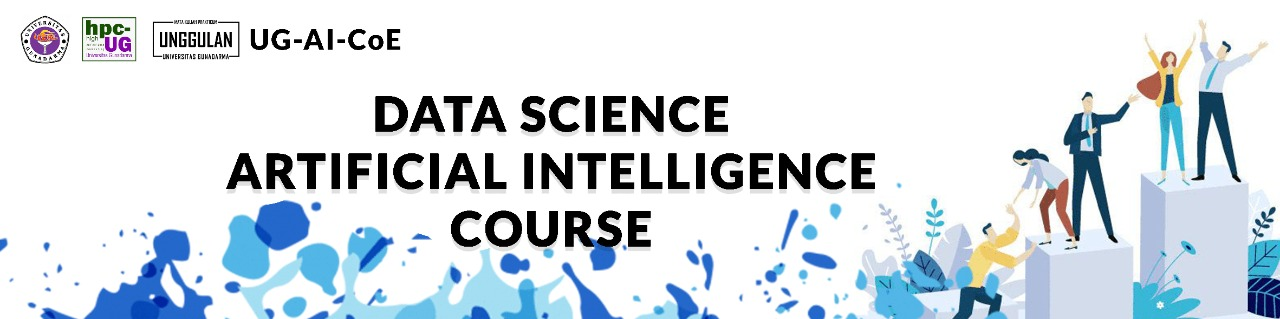

# Tugas Mandiri
---
Tugas mandiri ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

### Pertemuan 4 - Semester 7

## Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM


### Deskripsi Tugas
1. Mahasiswa harus membuat Project Data Science Sederhana dengan menggunakan algoritma clustering untuk menemukan kelompok atau pola tersembunyi pada suatu dataset.
2. Project dikerjakan secara lengkap mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, mulai dari Business Understanding hingga tahap Deployment.
3. Mahasiswa bebas memilih topik atau permasalahan yang relevan, selama project memiliki tujuan clustering yang jelas dan dataset memenuhi ketentuan yang telah ditetapkan.

### Ketentuan Dataset

Dataset yang digunakan harus memenuhi ketentuan berikut:
1. Berupa tabular dataset (.csv, .xlsx, atau sejenisnya).
2. Minimal 1000 baris dan 8 kolom.
3. Memiliki minimal 3 fitur numerik yang dapat digunakan untuk clustering.
4. Dataset memiliki karakteristik yang memungkinkan untuk dilakukan pengelompokan atau segmentasi.
5. Sumber dataset wajib dicantumkan dan berasal dari sumber yang jelas, seperti Kaggle, UCI, data.go.id, open data, atau dataset hasil pengumpulan sendiri.
6. Mahasiswa wajib menjelaskan secara singkat alasan dataset tersebut sesuai untuk permasalahan clustering.


<b>Catatan: Nilai akan dikurangi apabila dataset tidak memenuhi ketentuan.</b>

### Ketentuan Pengumpulan

Mahasiswa wajib mengumpulkan file berikut:
1. File Jupyter Notebook dengan format (`.ipynb`): Berisi seluruh proses CRISP-DM dari Business Understanding sampai Evaluation. **Notebook harus dapat dijalankan tanpa error.**

2. File Dataset: File dataset yang digunakan atau link sumber dataset.

3. Source Code Deployment
    <br> File yang digunakan untuk menjalankan aplikasi, misalnya: <br>
         

    *   app.py
    *   requirements.txt
    *   file konfigurasi atau file pendukung lainnya.


4. Link Deployment: Link aplikasi yang sudah dapat diakses melalui platform Streamlit.

<br>

<b>Seluruh file project dikumpulkan dalam satu folder Google Drive dengan akses *Anyone with the link → Editor*.</b> Tautan folder Google Drive kemudian dikumpulkan melalui Virtual Class sesuai dengan batas waktu yang telah ditentukan.

---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/

---

# Pengerjaan Tugas: Clustering Kualitas Wine dengan Metodologi CRISP-DM

Notebook ini melanjutkan instruksi tugas di atas. Seluruh tahapan CRISP-DM (Business Understanding sampai Evaluation) dikerjakan pada bagian di bawah ini.

## 1. Business Understanding

### Latar Belakang
Dataset yang digunakan adalah **Wine Quality Dataset (Red Wine)** yang berisi hasil uji fisikokimia terhadap sampel red wine. Setiap sampel memiliki beberapa ukuran kimiawi (kadar asam, gula, sulfur, alkohol, dll.) serta skor kualitas hasil penilaian panel. Dataset ini menarik untuk clustering karena memungkinkan kita menemukan kelompok wine dengan profil kimiawi yang mirip tanpa perlu melihat label kualitasnya terlebih dahulu.

### Permasalahan
Produsen wine ingin memahami apakah terdapat kelompok (profil) wine yang berbeda berdasarkan komposisi kimianya, dan apakah profil tersebut berkaitan dengan kualitas wine.

### Tujuan
Mengelompokkan sampel wine ke dalam beberapa cluster berdasarkan fitur fisikokimia menggunakan **K-Means Clustering**.

### Pertanyaan Analisis
1. Berapa jumlah cluster/profil wine yang optimal berdasarkan data?
2. Apa karakteristik kimiawi yang membedakan setiap cluster?
3. Apakah cluster yang terbentuk berkaitan dengan skor kualitas wine?

### Manfaat
Hasil clustering dapat membantu produsen wine memahami variasi profil produk mereka, sebagai dasar awal untuk quality control atau strategi blending, tanpa harus bergantung sepenuhnya pada penilaian manual.

## 2. Data Understanding

**Sumber dataset:** UCI Machine Learning Repository - *Wine Quality Data Set* (Cortez et al., 2009), red wine subset.
Link sumber: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Jumlah baris dan kolom:", df.shape)
df.info()

Jumlah baris dan kolom: (1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
print("Jumlah missing value per kolom:")
print(df.isna().sum())
print("\nJumlah data duplikat:", df.duplicated().sum())

Jumlah missing value per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Jumlah data duplikat: 240


**Interpretasi:** Dataset tidak memiliki missing value, namun terdapat sejumlah baris duplikat. Seluruh kolom bertipe numerik (`float64`/`int64`), sehingga tidak diperlukan proses encoding.

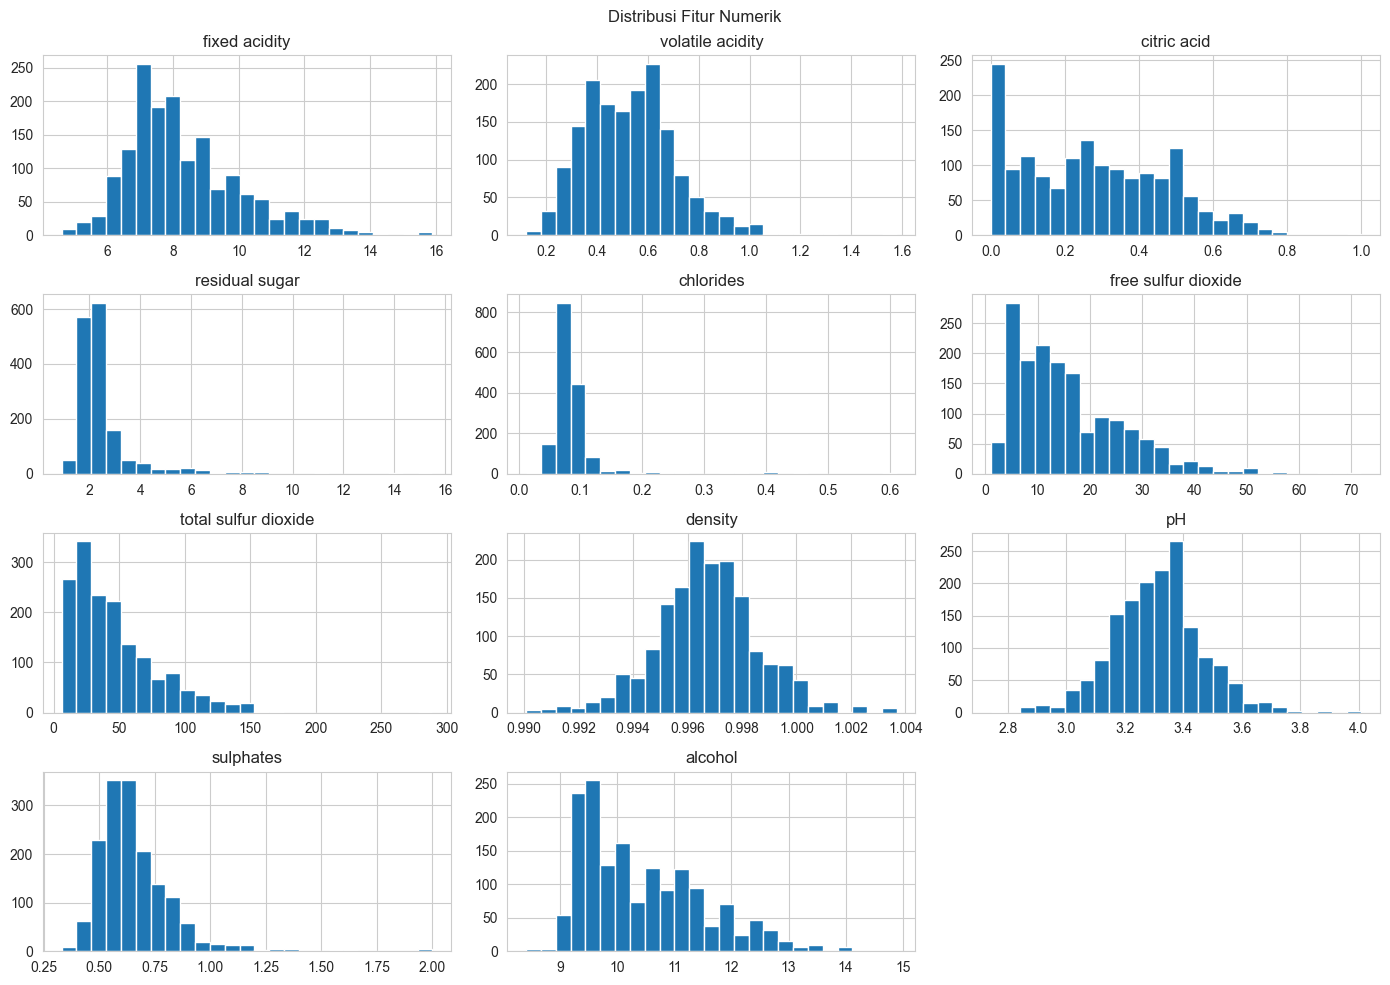

In [6]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol']

df[features].hist(figsize=(14, 10), bins=25)
plt.suptitle("Distribusi Fitur Numerik")
plt.tight_layout()
plt.show()

**Interpretasi:** Sebagian besar fitur (misalnya `residual sugar`, `chlorides`, `sulphates`) memiliki distribusi condong ke kanan (right-skewed) dengan beberapa nilai ekstrem, sedangkan `pH` dan `density` relatif mendekati distribusi normal.

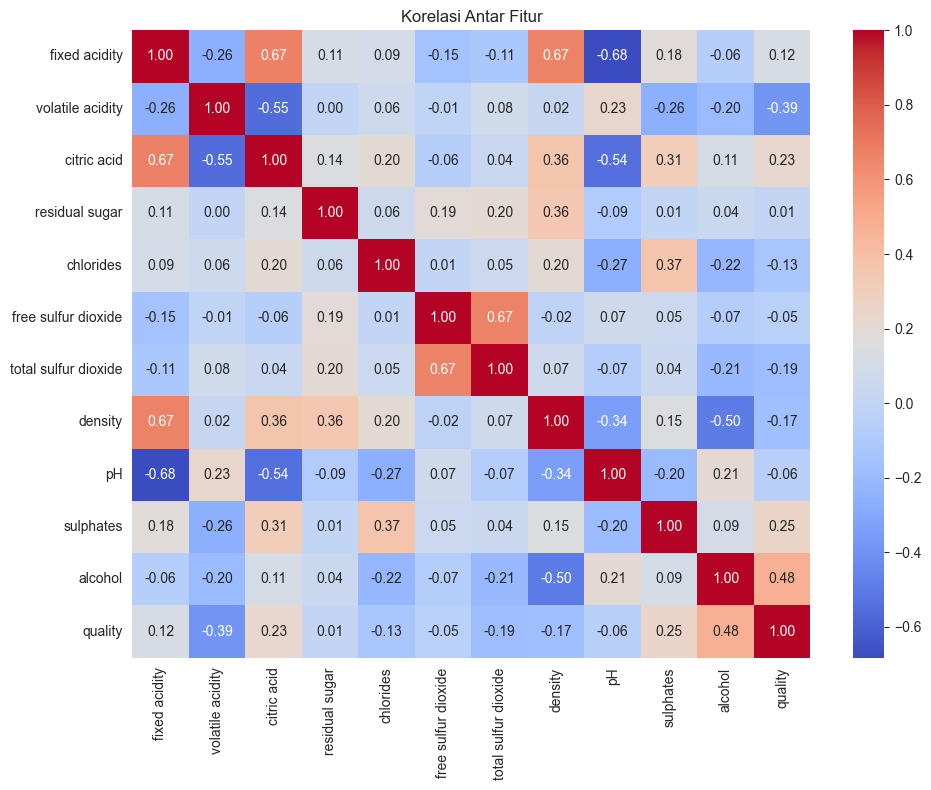

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ["quality"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

**Interpretasi:** `fixed acidity` berkorelasi kuat positif dengan `citric acid` dan `density`, serta berkorelasi negatif dengan `pH` (sesuai sifat kimia asam). `alcohol` memiliki korelasi positif paling kuat terhadap `quality`, sedangkan `volatile acidity` berkorelasi negatif terhadap `quality`.

## 3. Data Preparation

Langkah preprocessing yang dilakukan:
1. **Menghapus data duplikat**, agar tidak membias hasil clustering.
2. **Memilih fitur** fisikokimia (`features`) sebagai variabel clustering. Kolom `quality` **tidak diikutkan dalam proses clustering** karena merupakan skor penilaian, bukan sifat kimiawi wine — kolom ini hanya dipakai belakangan untuk memvalidasi hasil cluster.
3. **Scaling** dengan `StandardScaler`, karena satuan dan skala tiap fitur berbeda jauh (misalnya `total sulfur dioxide` berskala puluhan, sedangkan `chlorides` berskala kecil desimal), sehingga fitur dengan skala besar tidak mendominasi perhitungan jarak pada K-Means.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah baris setelah menghapus duplikat:", df.shape[0])

Jumlah baris setelah menghapus duplikat: 1359


In [9]:
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:3]

array([[-0.52443096,  0.93200015, -1.39325797, -0.46115707, -0.2456228 ,
        -0.46855352, -0.38404973,  0.58400336,  1.29187216, -0.57856134,
        -0.95437429],
       [-0.29406274,  1.91580043, -1.39325797,  0.05666484,  0.20009403,
         0.87200276,  0.60407328,  0.04873719, -0.70839548,  0.12482157,
        -0.5845748 ],
       [-0.29406274,  1.25993358, -1.18861732, -0.16525884,  0.07853489,
        -0.08553744,  0.2148127 ,  0.15579042, -0.32124691, -0.05102416,
        -0.5845748 ]])

## 4. Modeling

Jumlah cluster ditentukan menggunakan **Elbow Method** dan **Silhouette Score**, dicoba untuk k = 2 sampai 8.

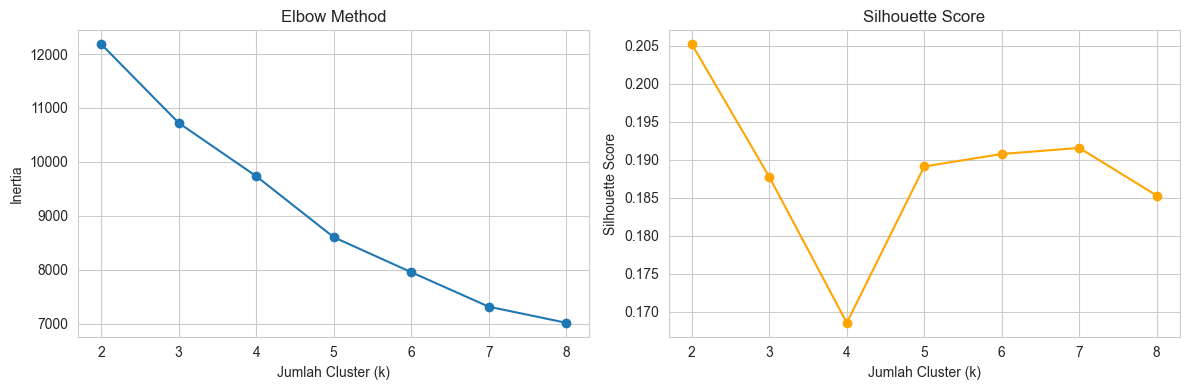

k=2 -> silhouette score = 0.2052
k=3 -> silhouette score = 0.1878
k=4 -> silhouette score = 0.1686
k=5 -> silhouette score = 0.1891
k=6 -> silhouette score = 0.1908
k=7 -> silhouette score = 0.1916
k=8 -> silhouette score = 0.1853


In [10]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_range), inertias, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Jumlah Cluster (k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(list(K_range), silhouettes, marker="o", color="orange")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Jumlah Cluster (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"k={k} -> silhouette score = {s:.4f}")

**Interpretasi:** Kurva elbow melandai secara bertahap tanpa titik patahan yang sangat tajam, sedangkan **Silhouette Score tertinggi diperoleh pada k = 2**. Oleh karena itu, **k = 2** dipilih sebagai jumlah cluster karena memberikan pemisahan kelompok paling jelas berdasarkan data yang ada, sekaligus menghasilkan segmentasi yang paling sederhana untuk diinterpretasikan.

In [11]:
k_final = 2

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
0    813
1    546
Name: count, dtype: int64

## 5. Visualisasi Hasil Clustering

Karena clustering menggunakan 11 fitur, hasil cluster divisualisasikan dalam 2 dimensi menggunakan **PCA (Principal Component Analysis)**.

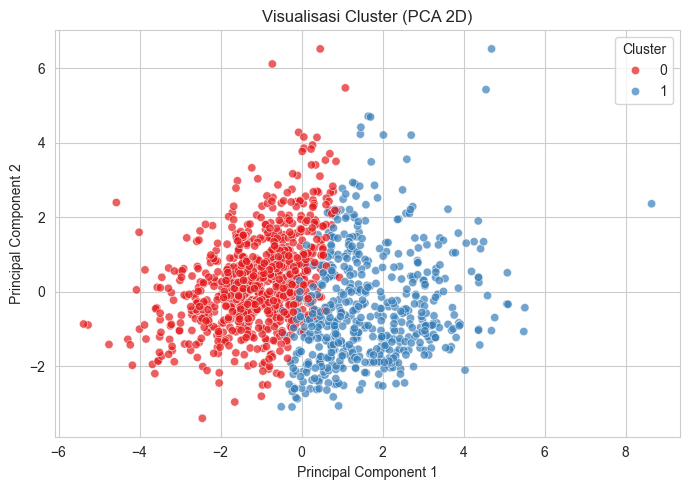

Variansi data yang dijelaskan 2 komponen PCA: 45.6%


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster"], palette="Set1", alpha=0.7)
plt.title("Visualisasi Cluster (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print(f"Variansi data yang dijelaskan 2 komponen PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

**Interpretasi:** Kedua cluster terlihat cukup terpisah pada ruang 2 dimensi hasil PCA, meskipun terdapat sedikit tumpang tindih di area perbatasan antar cluster — hal ini wajar mengingat data hasil pengukuran kimiawi bersifat kontinu dan tidak memiliki batas kelompok yang tegas.

## 6. Evaluation

In [13]:
sil_score = silhouette_score(X_scaled, df["cluster"])
db_score = davies_bouldin_score(X_scaled, df["cluster"])

print(f"Silhouette Score : {sil_score:.4f}")
print(f"Davies-Bouldin Index : {db_score:.4f}")

Silhouette Score : 0.2052
Davies-Bouldin Index : 1.8975


**Interpretasi:**
- **Silhouette Score** bernilai sekitar 0.2, yang tergolong rendah-menengah. Ini menunjukkan cluster yang terbentuk cukup terpisah namun tidak sepenuhnya rapat/kompak — wajar untuk data pengukuran kimiawi yang bersifat kontinu tanpa kelompok alami yang sangat tegas.
- **Davies-Bouldin Index** mendekati nilai 1.9; semakin kecil nilainya semakin baik pemisahan antar cluster.
- Secara keseluruhan, hasil clustering **cukup memberikan pemisahan kelompok yang dapat diinterpretasikan**, meskipun batas antar cluster tidak sepenuhnya tegas.

## 7. Analisis Karakteristik Cluster

In [14]:
cluster_profile = df.groupby("cluster")[features + ["quality"]].mean().round(3)
cluster_profile

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,
0,7.317,0.606,0.149,2.393,0.08,16.622,48.997,0.996,3.378,0.600,10.324,5.465
1,9.790,0.416,0.456,2.717,0.10,14.808,43.593,0.998,3.208,0.747,10.594,5.859


**Interpretasi karakteristik cluster** (berdasarkan rata-rata fitur di atas):

**Cluster 0** — jumlah anggota lebih banyak. Memiliki `fixed acidity` dan `citric acid` yang relatif rendah, `volatile acidity` yang lebih tinggi, serta `sulphates` yang lebih rendah dibanding Cluster 1. Rata-rata skor `quality` cluster ini sedikit lebih rendah.

**Cluster 1** — jumlah anggota lebih sedikit. Memiliki `fixed acidity` dan `citric acid` yang lebih tinggi, `volatile acidity` yang lebih rendah, serta `sulphates` yang lebih tinggi. Rata-rata skor `quality` cluster ini sedikit lebih tinggi dibanding Cluster 0.

Secara umum, Cluster 1 mencerminkan profil wine dengan keasaman tetap (fixed acidity) dan citric acid lebih tinggi serta keasaman volatil lebih rendah — kombinasi yang secara umum dikaitkan dengan kualitas rasa yang lebih baik, sejalan dengan rata-rata `quality` yang sedikit lebih tinggi pada cluster ini.

## 8. Hubungkan dengan Business Understanding

- **Pola yang ditemukan:** Data wine terbagi menjadi 2 profil kimiawi yang cukup berbeda, terutama pada tingkat keasaman (`fixed acidity`, `volatile acidity`, `citric acid`) dan `sulphates`.
- **Perbedaan antarcluster:** Cluster 1 cenderung memiliki profil asam yang lebih "stabil" (fixed acidity & citric acid tinggi, volatile acidity rendah) dibanding Cluster 0.
- **Menjawab pertanyaan analisis:** Ditemukan 2 profil wine yang optimal berdasarkan Silhouette Score, dengan karakteristik pembeda utama pada tingkat keasaman dan sulphates. Kedua cluster ini juga menunjukkan sedikit perbedaan rata-rata `quality`, sehingga profil kimiawi berkaitan dengan kualitas wine, walau tidak secara ekstrem.
- **Manfaat:** Produsen dapat menggunakan profil Cluster 1 (asam lebih stabil, sulphates lebih tinggi) sebagai referensi awal saat ingin mengarah pada kualitas wine yang lebih baik, tanpa harus menunggu penilaian kualitas manual secara lengkap.

## 9. Kesimpulan

Project ini berhasil melakukan clustering pada dataset Wine Quality menggunakan K-Means dengan k=2, dipilih berdasarkan Silhouette Score tertinggi. Hasil clustering menunjukkan 2 profil wine yang berbeda secara kimiawi dan memiliki keterkaitan dengan skor kualitas wine, sesuai dengan tujuan bisnis yang telah ditetapkan di awal. Hasil analisis ini selanjutnya digunakan sebagai dasar aplikasi Deployment menggunakan Streamlit (`app.py`).